# Adult Income - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the Adult Income dataset and identify preprocessing decisions required before feature engineering and machine learning.

This notebook focuses on:

- Data understanding
- Missing value analysis
- Feature distributions
- Relationships with target variable
- Outlier detection
- Correlation analysis
- Preprocessing recommendations

No feature engineering or model training is performed in this notebook.

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
df = pd.read_csv('/content/adult.csv', engine='python', on_bad_lines='skip')

**Data Inspection**

In [136]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [137]:
df.shape

(8222, 15)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8222 entries, 0 to 8221
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             8222 non-null   int64 
 1   workclass       8222 non-null   object
 2   fnlwgt          8222 non-null   int64 
 3   education       8222 non-null   object
 4   education.num   8222 non-null   int64 
 5   marital.status  8222 non-null   object
 6   occupation      8222 non-null   object
 7   relationship    8222 non-null   object
 8   race            8222 non-null   object
 9   sex             8222 non-null   object
 10  capital.gain    8222 non-null   int64 
 11  capital.loss    8222 non-null   int64 
 12  hours.per.week  8222 non-null   int64 
 13  native.country  8222 non-null   object
 14  income          8222 non-null   object
dtypes: int64(6), object(9)
memory usage: 963.6+ KB


In [139]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,8222.0,40.678910,13.587778,17.0,30.00,40.0,50.0,90.0
fnlwgt,8222.0,188971.876064,104360.168115,19302.0,117532.25,177136.0,238323.0,1033222.0
education.num,8222.0,10.500851,2.638903,1.0,9.00,10.0,13.0,16.0
capital.gain,8222.0,4267.735831,14226.892202,0.0,0.00,0.0,3325.0,99999.0
capital.loss,8222.0,345.743128,744.139631,0.0,0.00,0.0,0.0,4356.0
hours.per.week,8222.0,41.793238,12.195617,1.0,40.00,40.0,48.0,99.0


In [140]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


**Data cleaning**

In [141]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [142]:
df.replace('?',np.nan,inplace=True)

In [143]:
df.isnull().sum()

,0
age,0
workclass,455
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,455
relationship,0
race,0
sex,0


**Target Feature analysis**

<Axes: xlabel='income', ylabel='count'>

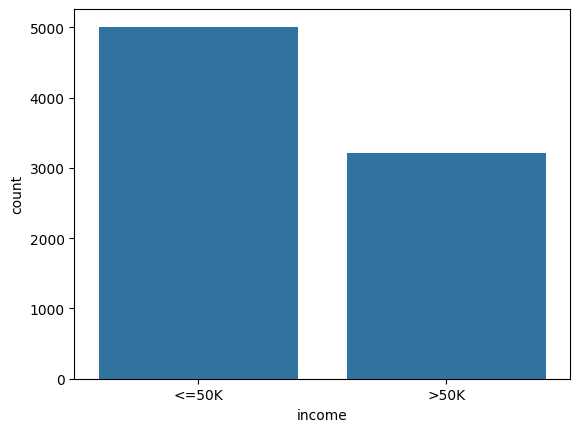

In [144]:
sns.countplot(data = df,x = 'income')

In [145]:
df['income'].value_counts(normalize= True)

,proportion
income,
<=50K,0.609219
>50K,0.390781



### Observation

- The majority of individuals belong to the <=50K income category.
- The >50K category represents a smaller portion of the dataset.

### Insight

The dataset exhibits class imbalance, which may affect model performance.

### Business Impact

Income prediction models may become biased toward the majority class if imbalance is not addressed.

**Univariate Analysis**

Categorical features

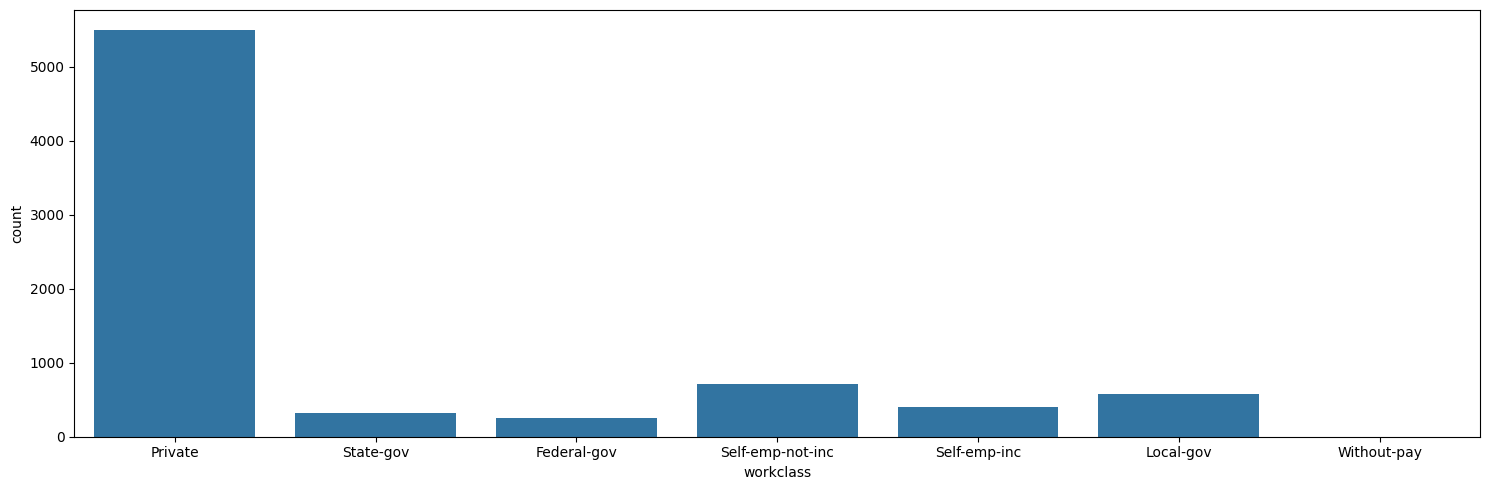

In [146]:
plt.figure(figsize=(15,5))
sns.countplot(data = df,x = 'workclass')
plt.tight_layout()
plt.show()

In [147]:
df['workclass'].value_counts(normalize=True)

,proportion
workclass,
Private,0.707609
Self-emp-not-inc,0.091412
Local-gov,0.074417
Self-emp-inc,0.051500
State-gov,0.041329
Federal-gov,0.033346
Without-pay,0.000386


### Objective

Analyze the employment sectors represented in the dataset.

### Observation

- Private sector employees form the largest group.
- Government and self-employed categories are less frequent.
- Missing values are present.

### Insight

Most individuals are employed in private organizations.

### Business Impact

Workclass may influence earning potential and should be evaluated against income.

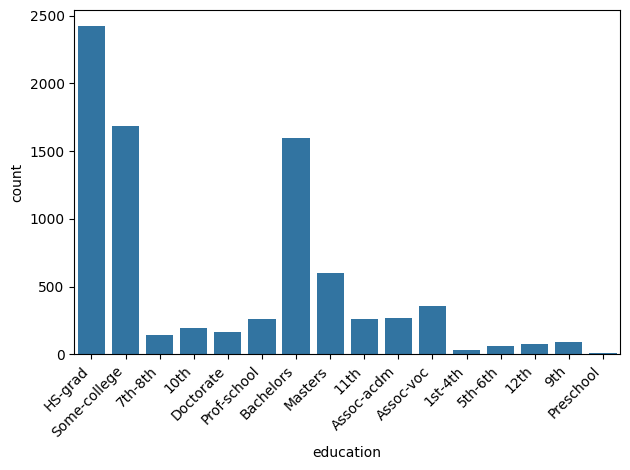

In [148]:
sns.countplot(data = df,x = 'education')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [149]:
df['education'].value_counts(normalize=True)

,proportion
education,
HS-grad,0.294332
Some-college,0.205060
Bachelors,0.194113
Masters,0.072732
Assoc-voc,0.043907
Assoc-acdm,0.032352
Prof-school,0.031866
11th,0.031501
10th,0.023352


### Observation

- High School Graduates are the largest group.
- Bachelor's and Some-college categories are also common.
- Advanced degrees are less frequent.

### Insight

The population is concentrated around secondary and undergraduate education levels.

### Business Impact

Education is expected to be a strong predictor of income.

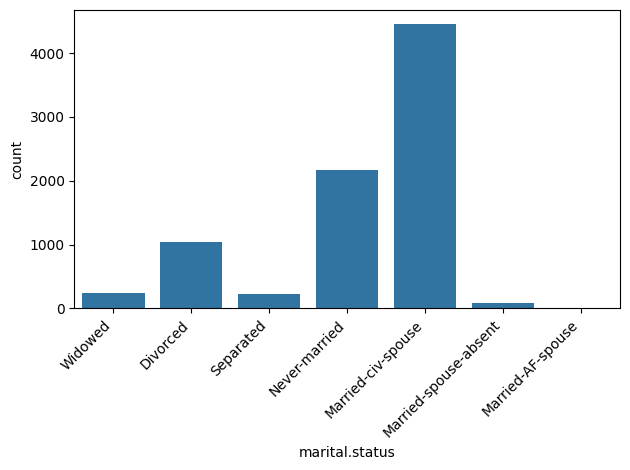

In [150]:
sns.countplot(data = df,x = 'marital.status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [151]:
df['marital.status'].value_counts(normalize=True)

,proportion
marital.status,
Married-civ-spouse,0.541596
Never-married,0.264413
Divorced,0.125760
Widowed,0.029920
Separated,0.026636
Married-spouse-absent,0.010825
Married-AF-spouse,0.000851


### Observation

- Never-married and Married-civ-spouse dominate the dataset.
- Divorced and separated individuals form smaller groups.

### Insight

The dataset contains diverse household structures.

### Business Impact

Marital status often correlates with earning capacity and financial stability.

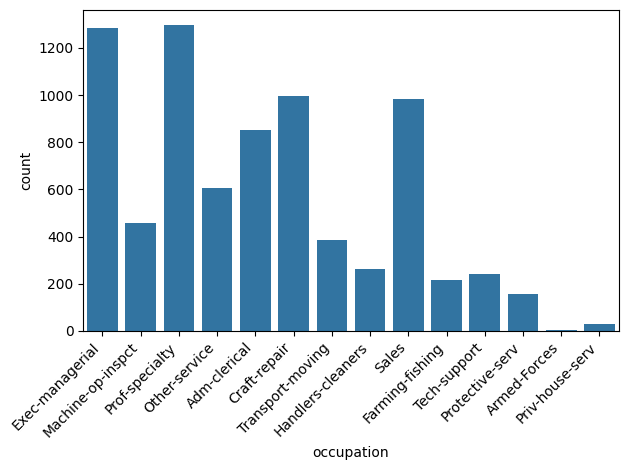

In [152]:
sns.countplot(data = df,x = 'occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [153]:
df['occupation'].value_counts(normalize=True)

,proportion
occupation,
Prof-specialty,0.166860
Exec-managerial,0.165315
Craft-repair,0.128364
Sales,0.126690
Adm-clerical,0.109695
Other-service,0.077765
Machine-op-inspct,0.058710
Transport-moving,0.049697
Handlers-cleaners,0.033604


### Observation

- Professional, managerial, and service occupations are highly represented.
- Certain occupations occur relatively infrequently.

### Insight

The workforce is distributed across multiple occupational groups.

### Business Impact

Occupation is likely to be one of the strongest income predictors.

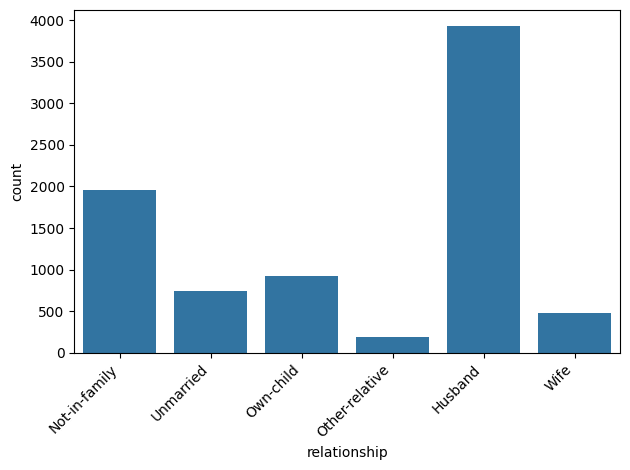

In [154]:
sns.countplot(data = df,x = 'relationship')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [155]:
df['relationship'].value_counts(normalize=True)

,proportion
relationship,
Husband,0.477256
Not-in-family,0.238385
Own-child,0.112381
Unmarried,0.090002
Wife,0.058623
Other-relative,0.023352


### Observation

- Husband and Not-in-family categories are common.
- Own-child and Other-relative categories are smaller.

### Insight

Household role distribution varies considerably.

### Business Impact

Relationship status may capture social and economic factors affecting income.

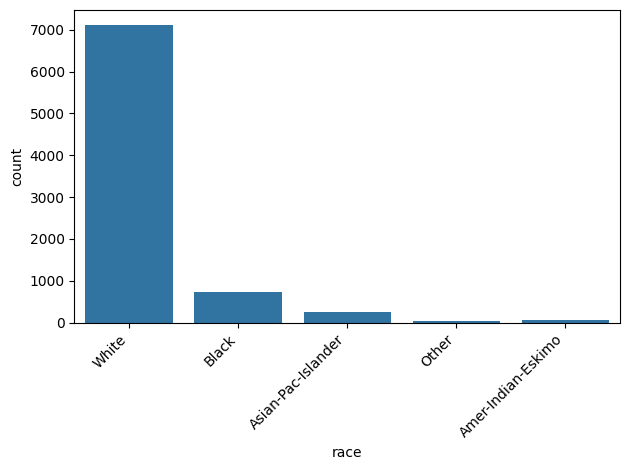

In [156]:
sns.countplot(data = df,x = 'race')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

- Certain racial groups dominate the dataset.
- Some groups have relatively low representation.

### Insight

The dataset is not uniformly distributed across racial categories.

### Business Impact

Race may influence observed income patterns and should be examined carefully.

<Axes: xlabel='sex', ylabel='count'>

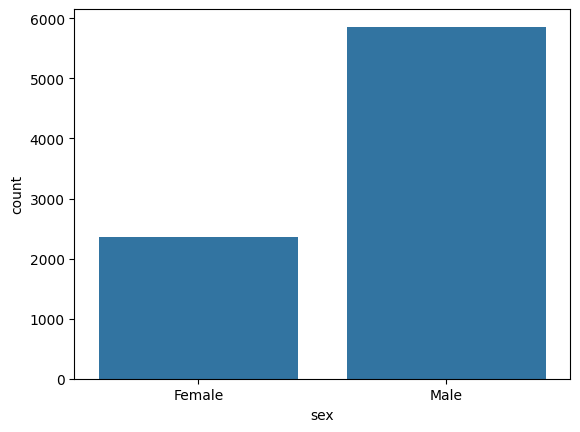

In [157]:
sns.countplot(data = df,x = 'sex')

### Observation

- Male individuals outnumber female individuals.

### Insight

The dataset contains an uneven gender distribution.

### Business Impact

Gender-based income differences may be present and require investigation.

In [158]:
top_10 = df['native.country'].value_counts().head(10).index

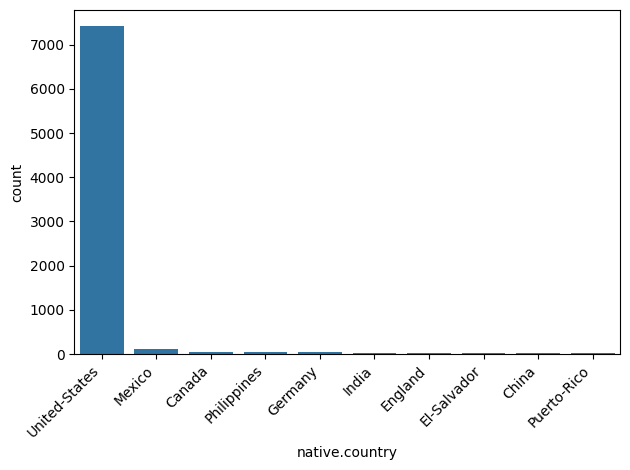

In [159]:
sns.countplot(data = df,x = 'native.country',order= top_10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

- The majority of individuals originate from the United States.
- Other countries have significantly smaller representation.

### Insight

The dataset is heavily centered around the U.S. population.

### Business Impact

Country-specific trends may exist but may be difficult to evaluate due to imbalance.

Numarical Features

<Axes: xlabel='age', ylabel='Count'>

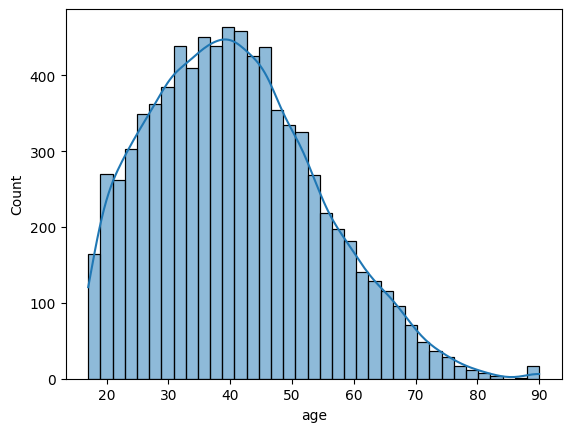

In [160]:
sns.histplot(data = df,x = 'age',kde = True)

### Observation

- Most individuals are between 20 and 50 years old.
- The distribution shows moderate right skewness.

### Insight

Working-age adults dominate the dataset.

### Business Impact

Age is expected to influence income due to experience and career progression.

<Axes: xlabel='fnlwgt', ylabel='Count'>

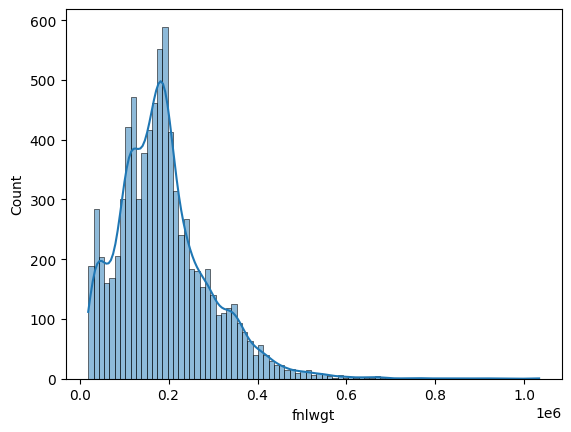

In [161]:
sns.histplot(data = df,x = 'fnlwgt',kde = True)

<Axes: xlabel='education.num', ylabel='Count'>

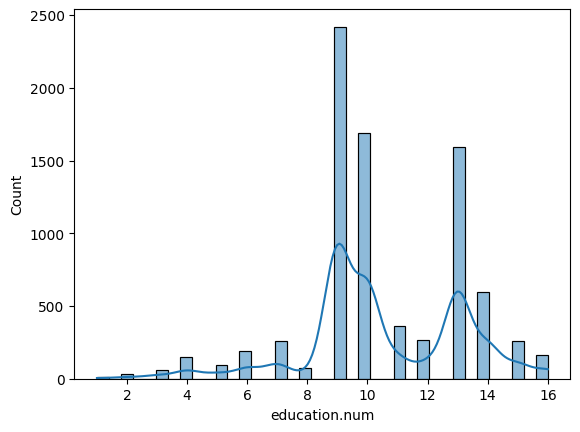

In [162]:
sns.histplot(data = df,x = 'education.num',kde = True)

<Axes: xlabel='capital.gain', ylabel='Count'>

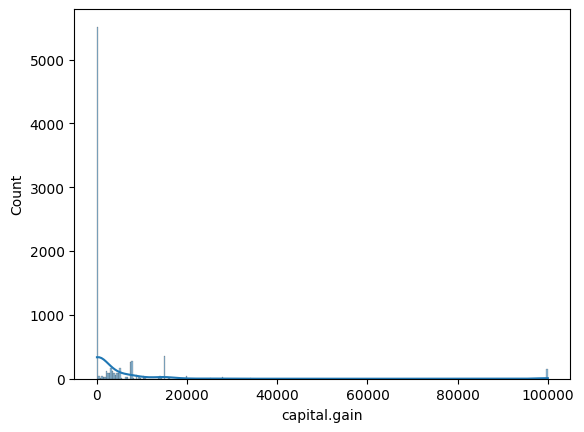

In [163]:
sns.histplot(data = df,x = 'capital.gain',kde = True)

### Observation

- Most observations contain zero capital gain.
- A small number of individuals have very large gains.

### Insight

The feature is highly right-skewed.

### Business Impact

Capital gain may strongly differentiate high-income individuals.

<Axes: xlabel='capital.loss', ylabel='Count'>

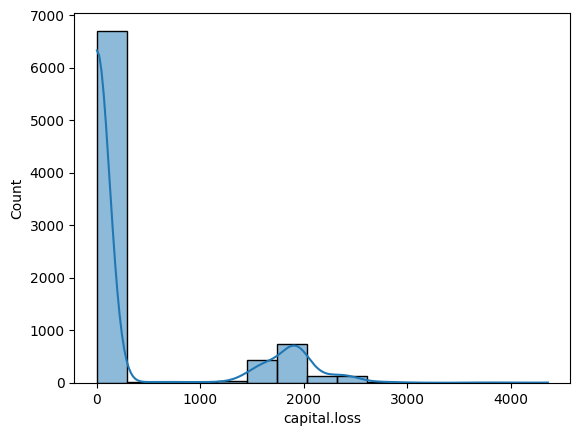

In [164]:
sns.histplot(data = df,x = 'capital.loss',kde = True)


### Observation

- Most observations contain zero capital loss.
- A small number of individuals report losses.

### Insight

The feature is sparse and heavily skewed.

### Business Impact

Capital loss may provide additional financial behavior information.

<Axes: xlabel='hours.per.week', ylabel='Count'>

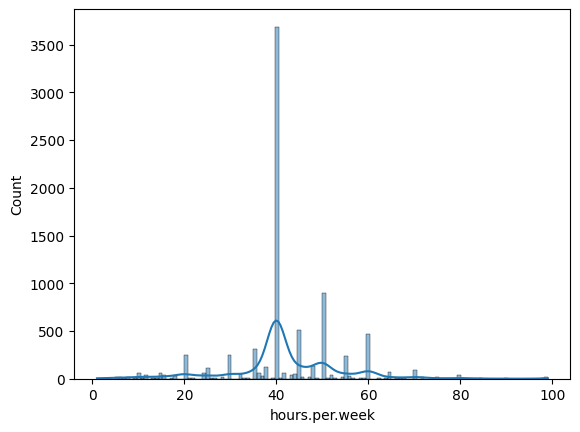

In [165]:
sns.histplot(data = df,x = 'hours.per.week',kde = True)

### Observation

- Most individuals work around 40 hours weekly.
- Some individuals work significantly longer hours.

### Insight

Standard full-time employment dominates the dataset.

### Business Impact

Workload may influence earning potential.

**Bivariat Analysis**

Categorical Features

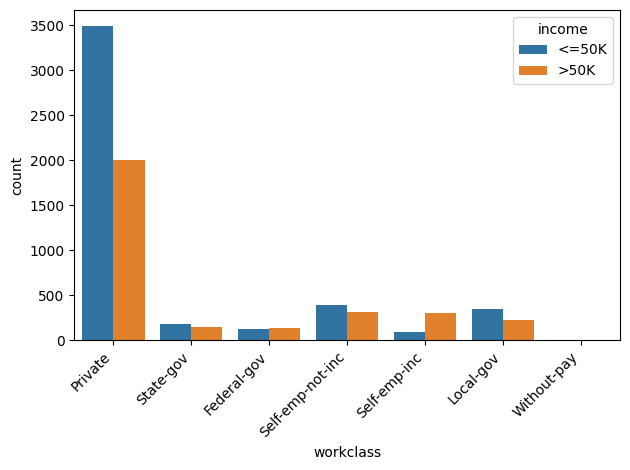

In [166]:
sns.countplot(data = df,x = 'workclass',hue = 'income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [167]:
df.groupby('workclass')['income'].value_counts(normalize= True)*100

workclass         income
Federal-gov       >50K       50.579151
                  <=50K      49.420849
Local-gov         <=50K      60.553633
                  >50K       39.446367
Private           <=50K      63.537118
                  >50K       36.462882
Self-emp-inc      >50K       75.750000
                  <=50K      24.250000
Self-emp-not-inc  <=50K      55.211268
                  >50K       44.788732
State-gov         <=50K      55.140187
                  >50K       44.859813
Without-pay       <=50K     100.000000
Name: proportion, dtype: float64

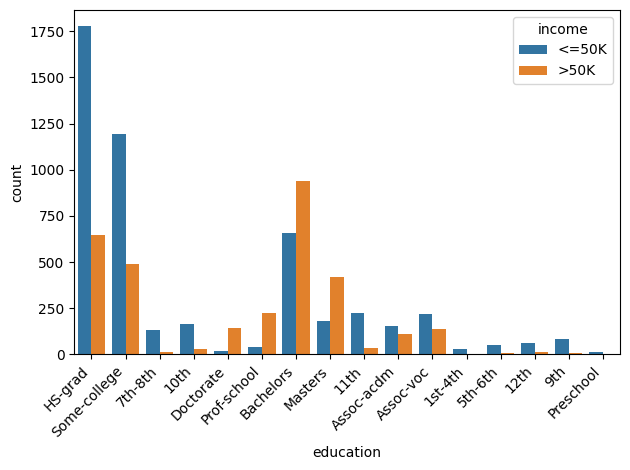

In [168]:
sns.countplot(data = df,x = 'education',hue = 'income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='education'>

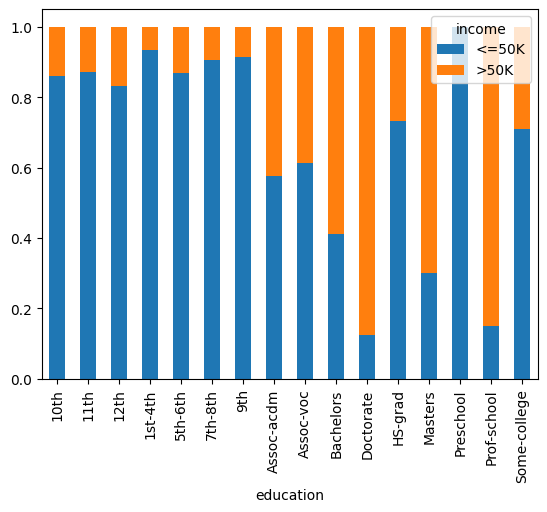

In [169]:
pd.crosstab(
    df['education'],
    df['income'],
    normalize='index'
).plot(kind='bar', stacked=True)

### Observation

- Higher education levels show larger proportions of >50K earners.
- Advanced degree holders outperform lower education groups.

### Insight

Education exhibits a strong positive relationship with income.

### Business Impact

Educational attainment appears to be a major driver of earning potential.

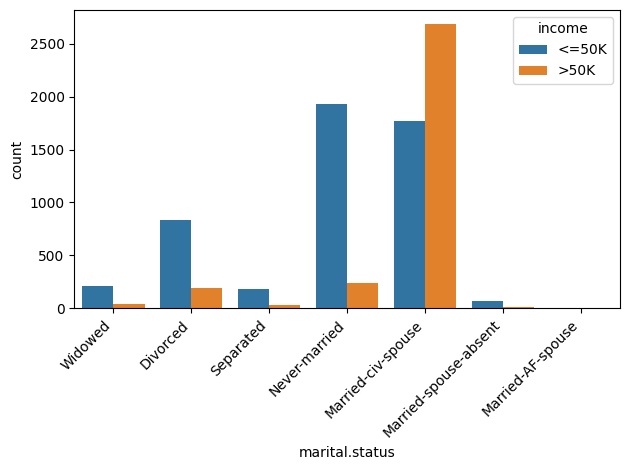

In [170]:
sns.countplot(data = df,x = 'marital.status',hue = 'income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

- Married individuals exhibit higher income levels.
- Never-married and separated individuals show lower proportions of >50K earners.

### Insight

Marital status is strongly associated with income.

### Business Impact

Household structure may contribute to economic outcomes.

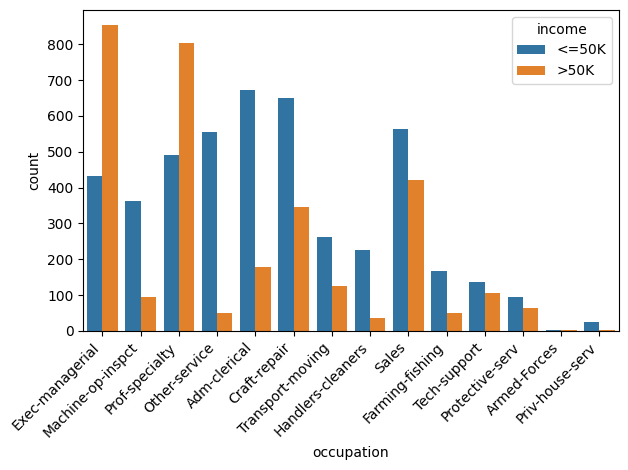

In [171]:
sns.countplot(data = df,x = 'occupation',hue = 'income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation

- Executive and professional occupations show the highest concentration of >50K earners.
- Service occupations show lower income levels.

### Insight

Occupation significantly impacts earning capacity.

### Business Impact

Occupation should be considered a high-priority predictive feature.

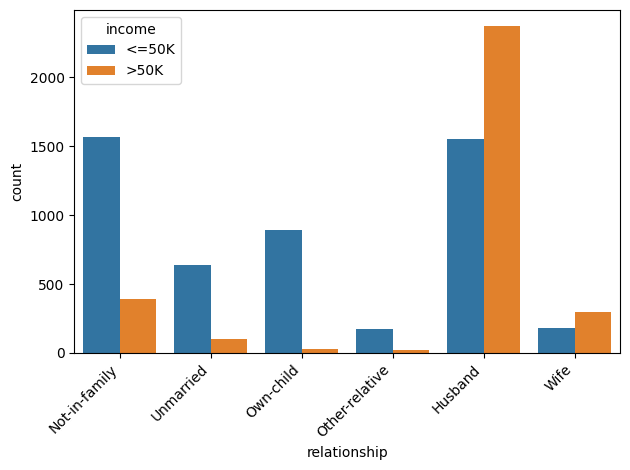

In [172]:
sns.countplot(data = df,x = 'relationship',hue = 'income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='race', ylabel='count'>

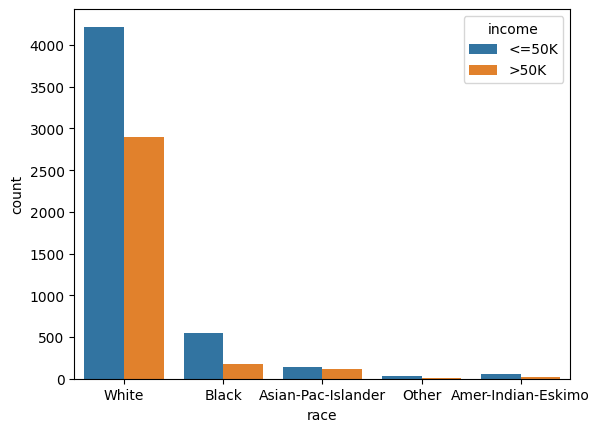

In [173]:
sns.countplot(data = df,x = 'race',hue = 'income')

## Race vs Income

### Objective

Analyze the relationship between race and income levels.

### Observation

- Income distribution varies across racial groups.
- Some groups have a higher proportion of >50K earners.

### Insight

Race exhibits differences in income distribution, although representation imbalance should be considered.

### Business Impact

Income prediction models may capture demographic patterns present in the dataset.

<Axes: xlabel='sex', ylabel='count'>

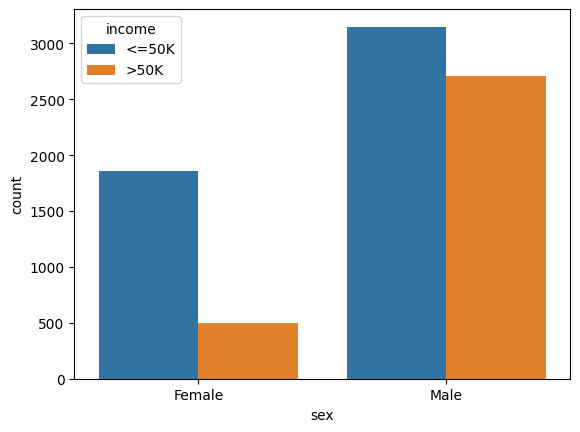

In [174]:
sns.countplot(data = df,x = 'sex',hue = 'income')

## Sex vs Income

### Objective

Evaluate how income differs across gender categories.

### Observation

- Male individuals show a larger proportion of >50K earners.
- Female individuals are more concentrated in the <=50K category.

### Insight

Gender appears associated with income levels within the dataset.

### Business Impact

Gender-related income disparities may influence predictive performance.

In [175]:
top_10 = df['native.country'].value_counts().head(10).index

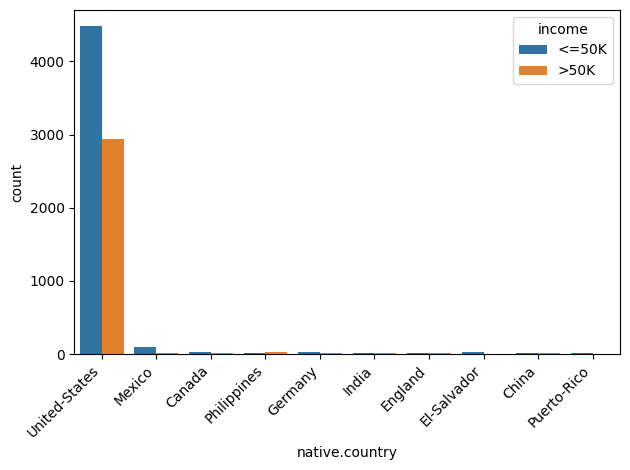

In [176]:
sns.countplot(data = df,x = 'native.country',hue = 'income',order = top_10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Native Country vs Income

### Objective

Analyze income distribution across countries of origin.

### Observation

- The United States dominates the dataset.
- Income proportions vary among countries.

### Insight

Geographic origin may influence income outcomes, though some countries have limited observations.

### Business Impact

Country-level patterns may contribute additional predictive information.

Numarical Features

<Axes: xlabel='income', ylabel='age'>

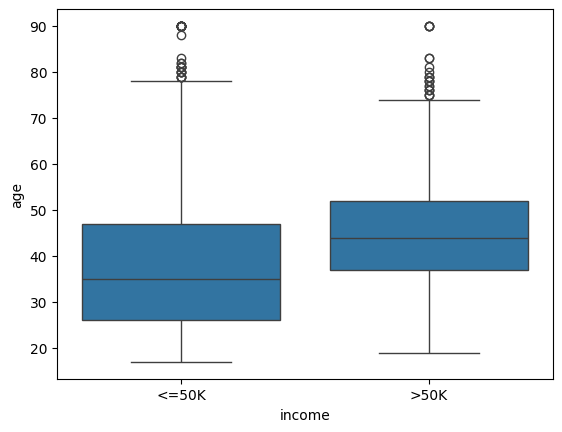

In [177]:
sns.boxplot(data=df,x='income',y='age')

## Age vs Income

### Objective

Analyze how age varies across income groups.

### Observation

- Individuals earning >50K tend to be older.
- The median age of high-income earners is higher.

### Insight

Age appears positively associated with income.

### Business Impact

Experience accumulated with age may contribute to higher earnings.


<Axes: xlabel='income', ylabel='fnlwgt'>

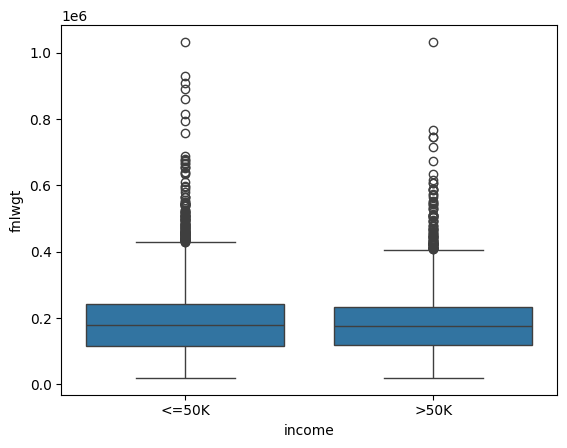

In [178]:
sns.boxplot(data=df,x='income',y='fnlwgt')

## fnlwgt vs Income

### Objective

Evaluate whether census weighting differs across income groups.

### Observation

- Significant overlap exists between income categories.
- No strong separation is visible.

### Insight

fnlwgt does not appear to provide strong business insight.

### Business Impact

This feature may have limited predictive value and should be reviewed during feature selection.

<Axes: xlabel='income', ylabel='education.num'>

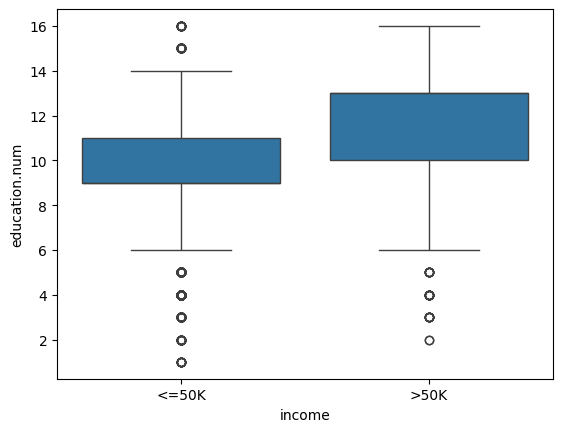

In [179]:
sns.boxplot(data=df,x='income',y='education.num')

## Education Number vs Income

### Objective

Assess the relationship between educational attainment and income.

### Observation

- Higher-income individuals generally possess higher education levels.
- Median education level is higher among >50K earners.

### Insight

Education shows a strong positive relationship with income.

### Business Impact

Education is likely to be an important predictor of income.

<Axes: xlabel='income', ylabel='capital.gain'>

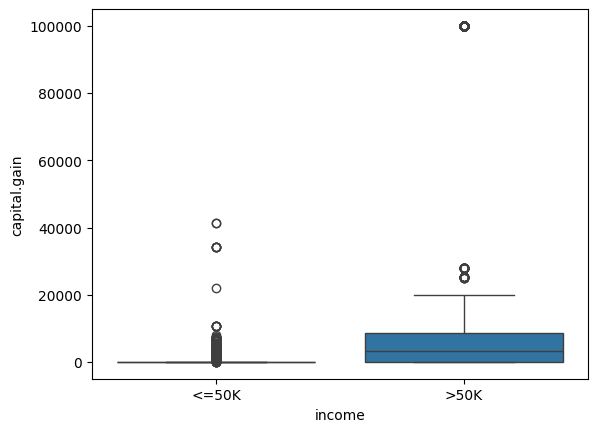

In [180]:
sns.boxplot(data=df,x='income',y='capital.gain')

## Capital Gain vs Income

### Objective

Analyze how investment gains differ across income groups.

### Observation

- Most individuals report zero capital gain.
- High-income earners show substantially larger capital gains.

### Insight

Capital gain strongly differentiates income groups.

### Business Impact

Investment-related features may significantly improve predictive performance.

<Axes: xlabel='income', ylabel='capital.loss'>

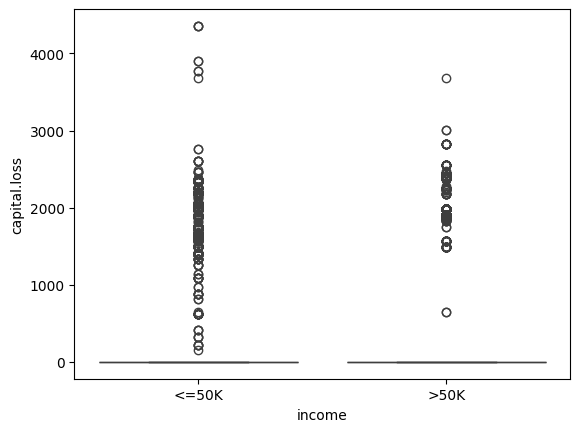

In [181]:
sns.boxplot(data=df,x='income',y='capital.loss')

## Capital Loss vs Income

### Objective

Analyze the relationship between capital loss and income.

### Observation

- Most observations contain zero values.
- Higher-income individuals exhibit slightly larger capital losses.

### Insight

Capital loss may contain useful information but appears less influential than capital gain.

### Business Impact

Capital loss may provide supplementary predictive power.

<Axes: xlabel='income', ylabel='hours.per.week'>

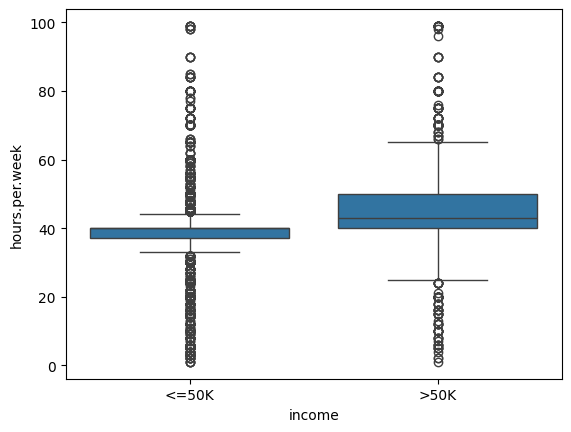

In [182]:
sns.boxplot(data=df,x='income',y='hours.per.week')

## Hours Worked vs Income

### Objective

Evaluate how working hours differ between income groups.

### Observation

- Higher-income individuals generally work more hours per week.
- Median working hours are higher among >50K earners.

### Insight

Working hours appear positively associated with income.

### Business Impact

Workload may contribute to earning potential.

**Multivariate Analysis**

<Axes: xlabel='age', ylabel='hours.per.week'>

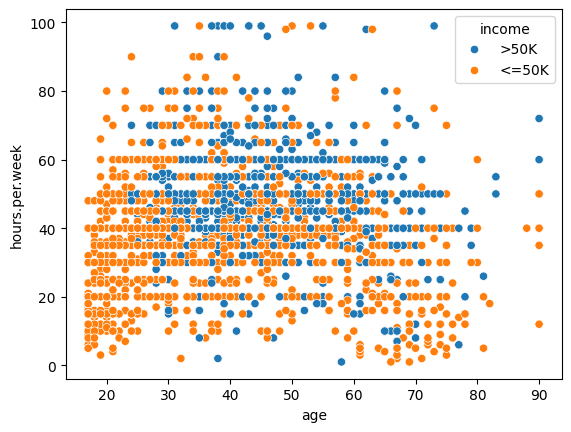

In [183]:
sns.scatterplot(
    data=df.sample(5000),
    x='age',
    y='hours.per.week',
    hue='income'
)

### Objective

Analyze how age and working hours jointly affect income.

### Insight

Higher-income individuals tend to cluster within specific age and working-hour ranges.

### Business Impact

Age and workload may interact to influence earning potential.

In [184]:
pd.crosstab(
    df['education'],
    df['occupation'],
    values=(df['income']=='>50K').astype(int),
    aggfunc='mean'
)

occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
education,,,,,,,,,,,,,,
10th,0.000000,NaN,0.189189,0.222222,0.100000,0.083333,0.100000,0.000000,0.0,1.000000,0.000000,0.150000,1.000000,0.350000
11th,0.000000,NaN,0.244444,0.555556,0.142857,0.120000,0.045455,0.020408,0.0,0.333333,1.000000,0.133333,0.000000,0.190476
12th,0.166667,NaN,0.363636,0.000000,NaN,0.250000,0.000000,0.000000,NaN,0.000000,0.000000,0.181818,0.000000,0.444444
1st-4th,NaN,NaN,0.000000,0.500000,0.000000,NaN,0.142857,0.000000,0.0,NaN,NaN,0.000000,NaN,0.000000
5th-6th,0.000000,NaN,0.166667,1.000000,0.000000,0.166667,0.181818,0.000000,0.0,NaN,NaN,0.500000,NaN,0.000000
7th-8th,0.000000,NaN,0.100000,0.333333,0.153846,0.000000,0.142857,0.000000,0.0,NaN,0.000000,0.000000,NaN,0.157895
9th,0.500000,NaN,0.052632,0.400000,0.000000,0.083333,0.052632,0.055556,0.0,0.000000,NaN,0.000000,0.000000,0.000000
Assoc-acdm,0.288889,NaN,0.500000,0.605263,0.166667,0.333333,0.750000,0.105263,NaN,0.433333,0.142857,0.595238,0.375000,0.500000
Assoc-voc,0.150943,NaN,0.491525,0.558824,0.000000,0.250000,0.380952,0.120000,0.0,0.641509,0.444444,0.363636,0.405405,0.357143


## Education, Occupation and Income

### Objective

Understand how education and occupation jointly influence income.

### Insight

The highest income proportions are concentrated among highly educated individuals in professional and managerial occupations.

### Business Impact

Combining education and occupation may create powerful predictive features.

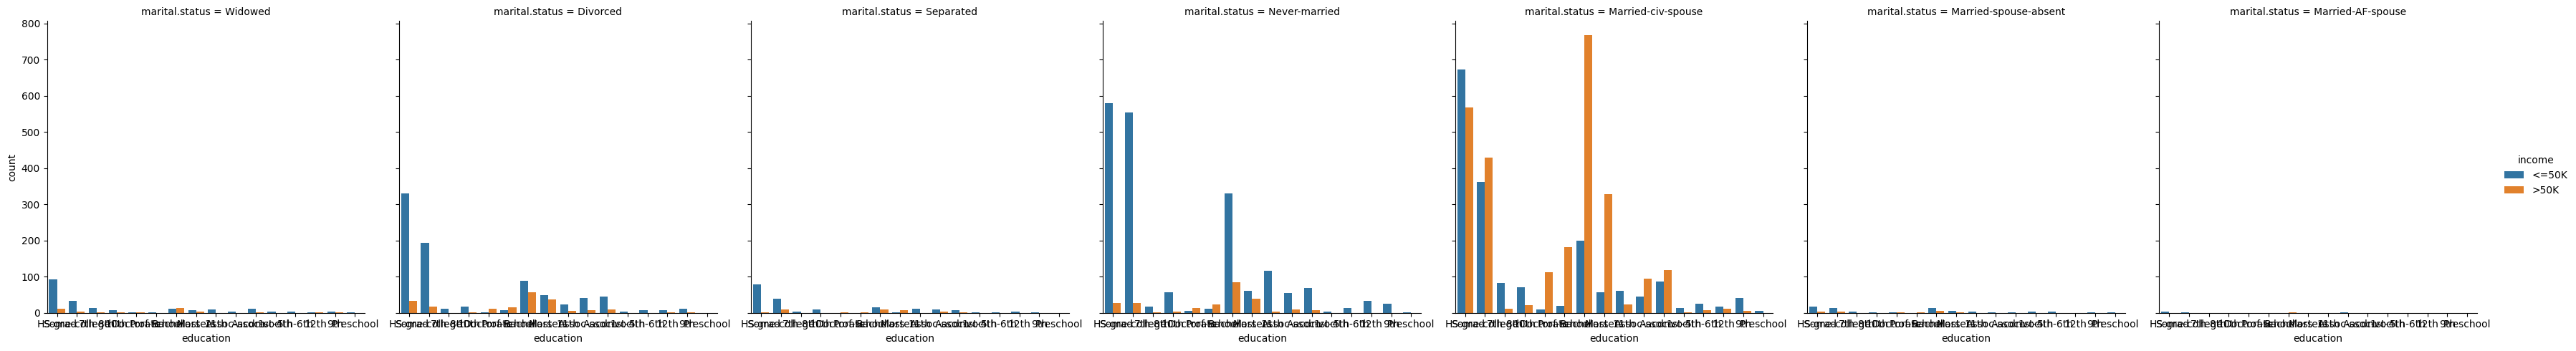

In [185]:
sns.catplot(
    data=df,
    x='education',
    hue='income',
    col='marital.status',
    kind='count'
)

## Household Structure and Income

### Objective

Analyze how marital status and household role jointly affect income.

### Insight

Income levels vary significantly across household structures.

### Business Impact

Combining household-related features may improve model performance.

<Axes: xlabel='income', ylabel='age'>

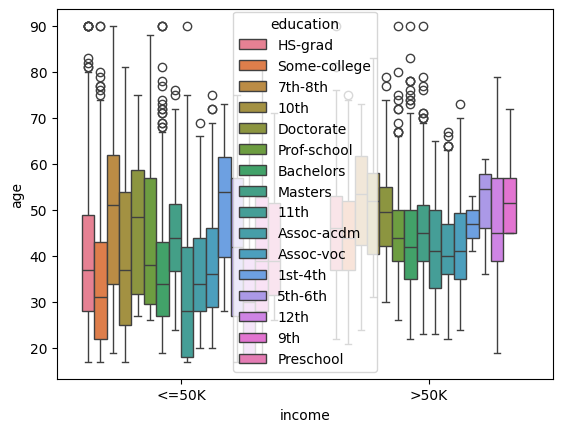

In [186]:
sns.boxplot(
    data=df,
    x='income',
    y='age',
    hue='education'
)


<Axes: >

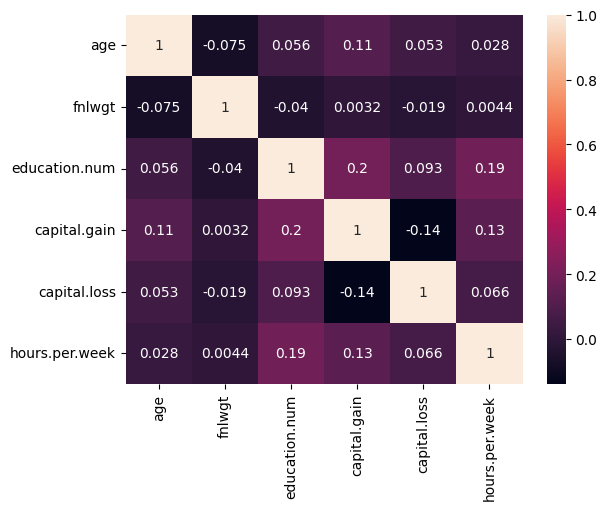

In [187]:
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True
)

## Correlation Analysis

### Objective

Identify relationships among numerical variables.

### Insight

Most numerical features exhibit weak linear correlations, indicating that non-linear relationships may exist.

### Business Impact

Feature engineering may uncover hidden predictive power.

# Recommended Feature Engineering

1. Create Age Groups
2. Create Education Levels
3. Create Work Hour Categories
4. Create Investment Activity Flag
5. Group Marital Status Categories
6. Group Occupation Categories
7. Create Capital Activity Feature

# Executive Summary

Key Findings:

1. Education strongly influences income.
2. Occupation is one of the strongest predictors of earnings.
3. Married individuals are more likely to belong to the >50K income group.
4. Capital gains are highly concentrated among high-income individuals.
5. Age and working hours contribute to earning potential.
6. Relationship status provides significant predictive information.

Recommended Feature Engineering:

- Age Groups
- Education Levels
- Work Hour Categories
- Investment Activity Flag
- Marital Groups
- Occupation Clusters

The dataset is suitable for building a binary classification model to predict whether an individual's income exceeds $50,000 annually.